# Redes Neuronales

In [13]:
#!pip install tensorflow

In [14]:
from dotenv import load_dotenv
import os

load_dotenv()  # carga automáticamente el .env de la raíz

DATA_DIR           = os.getenv("DATA_DIR", "./data")
RAW_DATA_PATH      = os.getenv("RAW_DATA_PATH", "./data/raw/dataset.xlsx")
PROCESSED_DATA_PATH= os.getenv("PROCESSED_DATA_PATH", "./data/processed/dataset_procesado.pkl")
MODELS_DIR         = os.getenv("MODELS_DIR", "./models")
RANDOM_SEED        = int(os.getenv("RANDOM_SEED", 42))

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import warnings
import re
warnings.filterwarnings('ignore')

from keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from keras.models import Sequential
from keras.callbacks import EarlyStopping
from tf_keras.preprocessing.text import Tokenizer
from tf_keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, 
                             ConfusionMatrixDisplay, precision_recall_curve, 
                             roc_auc_score, roc_curve, cohen_kappa_score)

np.random.seed(42)
tf.random.set_seed(42)
print(f"TensorFlow: {tf.__version__}")

TensorFlow: 2.21.0


## LSTM con datos críticos (rad_criticos.xlsx)

**Objetivo:** Entrenar el LSTM bidireccional sobre los datos críticos sin augmentación para establecer la línea base a comparar contra las estrategias LLM y ROS.

In [16]:
# =============================================================================
# CARGA DE DATOS CRÍTICOS (rad_criticos.xlsx) — sin augmentación
# Entrenamiento LSTM en celda separada, después de definir la arquitectura.
# =============================================================================
from pathlib import Path as _Path

_pos = [_Path('../data'), _Path('data'), _Path.cwd()/'data', _Path.cwd().parent/'data']
_candidates = []
if 'DATA_DIR' in dir():
    _env_dir = _Path(DATA_DIR)
    _candidates.append(_env_dir)
    if not _env_dir.is_absolute():
        _candidates.append((_Path.cwd() / _env_dir))
_candidates.extend(_pos)

_crit_path = next((
    p.resolve() / 'rad_criticos.xlsx'
    for p in _candidates
    if (p / 'rad_criticos.xlsx').exists()
), None)
if _crit_path is None:
    raise FileNotFoundError("No se encontró 'rad_criticos.xlsx' en rutas conocidas.")

DATA_DIR = _crit_path.parent
df_criticos_raw = pd.read_excel(_crit_path)
for _col in ['Hallazgos', 'Opinión']:
    df_criticos_raw[_col] = df_criticos_raw[_col].fillna('').astype(str)
df_criticos_raw['texto'] = df_criticos_raw['Hallazgos'] + ' ' + df_criticos_raw['Opinión']

patologias = ['acv', 'hemorragia', 'desviacion_linea_media', 'fractura_compleja_craneo']
# Normalizar nombres de columnas para evitar errores de mayúsculas/minúsculas
_col_map = {c.lower().strip(): c for c in df_criticos_raw.columns}
_rename_map = {_col_map[p]: p for p in patologias if p in _col_map}
df_criticos_raw = df_criticos_raw.rename(columns=_rename_map)

_missing = [p for p in patologias if p not in df_criticos_raw.columns]
if _missing:
    print(f"Columnas faltantes; se generarán por reglas: {_missing}")
    _text_col = 'Hallazgos' if 'Hallazgos' in df_criticos_raw.columns else 'texto'
    if _text_col not in df_criticos_raw.columns:
        raise KeyError("No se encontró una columna de texto para generar etiquetas.")

    KEYWORDS_NEGATIVOS_GLOBAL = [
        'antiguo','antigua','cronico','cronica','crónico','crónica',
        'viejo','vieja','residual','residuales','secuela','secuelar','secuelas',
        'previo','previa','previos','previas','conocido','conocida',
        'ya descrito','ya visualizado','sin cambios','estable','resolucion','resolución'
    ]
    NEGACIONES_CONTEXTUALES = [
        'sin','descarta','descartado','descartada','negativo','negativa',
        'ausencia','ausente','ausentes','sin evidencia','sin signos',
        'no se observa','no se observan','no se evidencia','no se evidencian',
        'no se identifica','no se identifican','libre de','negativo para',
        'negativa para'
    ]
    def detectar_patologia_robusta(texto, keywords_pos, keywords_neg=None):
        if not isinstance(texto, str):
            return 0
        texto = texto.lower()
        keywords_neg = keywords_neg or KEYWORDS_NEGATIVOS_GLOBAL
        kw_ord = sorted(keywords_pos, key=len, reverse=True)
        oraciones = re.split(r'[.;]', texto)
        for oracion in oraciones:
            oracion = oracion.strip()
            kw_encontrada = next((kw for kw in kw_ord if kw in oracion), None)
            if not kw_encontrada:
                continue
            if re.search(re.escape(kw_encontrada) + r'\s*:\s*no\b', oracion):
                continue
            if re.search(re.escape(kw_encontrada) + r'\s*:[^.;]*?\b(no|negativo|negativa|ausente)\b', oracion):
                continue
            idx_kw = oracion.find(kw_encontrada)
            segmento_previo = oracion[max(0, idx_kw-50):idx_kw]
            if any(neg in segmento_previo for neg in NEGACIONES_CONTEXTUALES):
                continue
            if re.search(r'sin\s+(hallazgos?|evidencia|signos?)\s+(indirectos?\s+)?(de\s+)?' + re.escape(kw_encontrada), oracion):
                continue
            if any(ant in oracion for ant in keywords_neg):
                continue
            if 'sin cambios' in oracion and kw_encontrada in oracion:
                continue
            return 1
        return 0

    KW_HEMORRAGIA = [
        'hemorragia subaracnoidea','hematoma subdural','hematoma epidural',
        'sangrado intraparenquimatoso','sangrado intraventricular',
        'hemorragia intraparenquimatosa','hemorragia intraventricular',
        'foco hemorragico','focos hemorragicos','hemorragia','hematoma','sangrado',
    ]
    KW_ACV = [
        'infarto cerebral','infarto lacunar','infartos lacunares',
        'evento isquemico','evento cerebrovascular','area de isquemia',
        'hipodensidad cortical','hipodensidad subcortical',
        'infarto','isquemia','isquemico','isquemica','ictus','acv',
    ]
    KW_FRACTURA = [
        'fractura con hundimiento','fractura hundimiento','fractura deprimida',
        'fractura conminuta','fractura compleja','fractura de base de craneo',
        'fractura craneofacial','fractura multiple de craneo',
    ]
    KW_DLM = [
        'desviacion de la linea media','desviacion linea media',
        'linea media desplazada','desplazamiento de la linea media',
        'shift de linea media','herniacion subfalcina','hernia subfalcina',
    ]
    df_criticos_raw['hemorragia'] = df_criticos_raw[_text_col].apply(
        lambda x: detectar_patologia_robusta(x, KW_HEMORRAGIA))
    df_criticos_raw['acv'] = df_criticos_raw[_text_col].apply(
        lambda x: detectar_patologia_robusta(x, KW_ACV))
    df_criticos_raw['fractura_compleja_craneo'] = df_criticos_raw[_text_col].apply(
        lambda x: detectar_patologia_robusta(x, KW_FRACTURA))
    df_criticos_raw['desviacion_linea_media'] = df_criticos_raw[_text_col].apply(
        lambda x: detectar_patologia_robusta(x, KW_DLM))

    _missing = [p for p in patologias if p not in df_criticos_raw.columns]
    if _missing:
        raise KeyError(f"Faltan columnas de patología en rad_criticos.xlsx: {_missing}")

_stratify_col = df_criticos_raw['hemorragia'] if 'hemorragia' in df_criticos_raw.columns else None
if _stratify_col is not None and _stratify_col.nunique() < 2:
    print("Aviso: 'hemorragia' no tiene suficientes clases para estratificar; se desactiva.")
    _stratify_col = None

df_crit_train, df_crit_test = train_test_split(
    df_criticos_raw, test_size=0.2, random_state=RANDOM_SEED,
    stratify=_stratify_col)

X_crit_train_text = df_crit_train['texto'].astype(str).values
X_crit_test_text  = df_crit_test['texto'].astype(str).values
y_crit_train_arr  = df_crit_train[patologias].values
y_crit_test_arr   = df_crit_test[patologias].values

print(f'Críticos — Train: {len(df_crit_train)} | Test: {len(df_crit_test)}')
for p in patologias:
    n = int(df_crit_train[p].sum())
    print(f'  {p:<35}  Train+: {n:3d} ({100*n/len(df_crit_train):5.1f}%)  Test+: {int(df_crit_test[p].sum()):2d}')
print('\n(Entrenamiento LSTM se ejecuta en la celda de esta sección',
      ' después de definir la arquitectura.)')


Columnas faltantes; se generarán por reglas: ['acv', 'hemorragia', 'desviacion_linea_media', 'fractura_compleja_craneo']
Críticos — Train: 761 | Test: 191
  acv                                  Train+: 341 ( 44.8%)  Test+: 85
  hemorragia                           Train+: 616 ( 80.9%)  Test+: 155
  desviacion_linea_media               Train+:  34 (  4.5%)  Test+: 12
  fractura_compleja_craneo             Train+:  27 (  3.5%)  Test+:  2

(Entrenamiento LSTM se ejecuta en la celda de esta sección  después de definir la arquitectura.)


In [17]:
# =============================================================================
# CARGA DE DATOS AUMENTADOS CON LLM
# Fuente: train_augmentado_llm.xlsx
#   - Train: datos reales + sintéticos (LLM augmentation)
#   - Test:  solo datos reales (sin aumentar)
# Para ACV: train aumentado adicionalmente con Train_ROS (boost de minoría)
# =============================================================================

from pathlib import Path

posibles_rutas_base = [
    Path('../data'),
    Path('data'),
    Path.cwd() / 'data',
    Path.cwd().parent / 'data'
]

DATA_DIR = next((p.resolve() for p in posibles_rutas_base if p.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError("No se encontró el directorio 'data'.")

LLM_PATH = DATA_DIR / 'train_augmentado_llm.xlsx'
ROS_PATH  = DATA_DIR / 'train_oversampling_data.xlsx'

if not LLM_PATH.exists():
    raise FileNotFoundError(f"No se encontró '{LLM_PATH}'.")

df_train = pd.read_excel(LLM_PATH, sheet_name='Train')
df_test  = pd.read_excel(LLM_PATH, sheet_name='Test')

for df_ in [df_train, df_test]:
    df_['Hallazgos'] = df_['Hallazgos'].fillna('').astype(str)
    df_['Opinión']   = df_['Opinión'].fillna('').astype(str)
    df_['texto']     = df_['Hallazgos'] + ' ' + df_['Opinión']

patologias = ['acv', 'hemorragia', 'desviacion_linea_media', 'fractura_compleja_craneo']

# Cargar ROS para boost de ACV
if ROS_PATH.exists():
    df_ros = pd.read_excel(ROS_PATH, sheet_name='Train_ROS')
    df_ros['Hallazgos'] = df_ros['Hallazgos'].fillna('').astype(str)
    df_ros['Opinión']   = df_ros['Opinión'].fillna('').astype(str)
    df_ros['texto']     = df_ros['Hallazgos'] + ' ' + df_ros['Opinión']
    df_train_acv = pd.concat([df_train, df_ros], ignore_index=True)
else:
    df_train_acv = df_train.copy()
    print("⚠️  Train_ROS no disponible — ACV usa solo datos LLM.")

df = df_train  # alias para compatibilidad

print(f"Train LLM:       {len(df_train)} registros  {df_train['tipo'].value_counts().to_dict()}")
print(f"Train ACV boost: {len(df_train_acv)} registros (LLM + ROS)")
print(f"Test:            {len(df_test)} registros (solo reales)")

print("\nEtiquetas — Train:")
for p in patologias:
    n = int(df_train[p].sum())
    print(f"  {p:<35s}: {n:4d}  ({100*n/len(df_train):.1f}%)")

print("\nEtiquetas — Test:")
for p in patologias:
    n = int(df_test[p].sum())
    print(f"  {p:<35s}: {n:4d}  ({100*n/len(df_test):.1f}%)")

Train LLM:       1334 registros  {'real': 809, 'sintetico': 525}
Train ACV boost: 2095 registros (LLM + ROS)
Test:            143 registros (solo reales)

Etiquetas — Train:
  acv                                :  277  (20.8%)
  hemorragia                         :  687  (51.5%)
  desviacion_linea_media             :  332  (24.9%)
  fractura_compleja_craneo           :  325  (24.4%)

Etiquetas — Test:
  acv                                :   46  (32.2%)
  hemorragia                         :  126  (88.1%)
  desviacion_linea_media             :   22  (15.4%)
  fractura_compleja_craneo           :    5  (3.5%)


In [18]:
# =============================================================================
# ETIQUETAS: pre-computadas en train_augmentado_llm.xlsx
# Las columnas acv, hemorragia, desviacion_linea_media, fractura_compleja_craneo
# ya están disponibles — NO se re-etiquetan aquí.
# La función detectar_patologia_robusta se mantiene como referencia histórica
# pero no se aplica sobre el dataset aumentado.
# =============================================================================

print("Etiquetas verificadas en el dataset aumentado:")
print(f"{'Patología':<35s}  {'Train+':>6}  {'Test+':>5}")
print("-" * 52)
for p in patologias:
    n_tr = int(df_train[p].sum())
    n_te = int(df_test[p].sum())
    print(f"  {p:<35s}  {n_tr:>6}  {n_te:>5}")

Etiquetas verificadas en el dataset aumentado:
Patología                            Train+  Test+
----------------------------------------------------
  acv                                     277     46
  hemorragia                              687    126
  desviacion_linea_media                  332     22
  fractura_compleja_craneo                325      5


In [19]:
# Extraer X e y desde los splits pre-definidos (sin train_test_split)
X_train_text     = df_train['texto'].astype(str).values
X_test_text      = df_test['texto'].astype(str).values
X_train_text_acv = df_train_acv['texto'].astype(str).values

y_train = df_train[patologias].values
y_test  = df_test[patologias].values

print(f"Train: {len(X_train_text)} muestras | Test: {len(X_test_text)} muestras")
print(f"Train ACV (LLM+ROS): {len(X_train_text_acv)} muestras")
print(f"Longitud promedio texto — Train: {np.mean([len(t.split()) for t in X_train_text]):.0f} palabras")
print(f"Longitud promedio texto — Test:  {np.mean([len(t.split()) for t in X_test_text]):.0f} palabras")
print()
print("Distribución de etiquetas — Train:")
for i, p in enumerate(patologias):
    n = int(y_train[:, i].sum())
    print(f"  {p:<35s}: {n:4d}  ({100*n/len(y_train):.1f}%)")

print("\nDistribución de etiquetas — Test:")
for i, p in enumerate(patologias):
    n = int(y_test[:, i].sum())
    print(f"  {p:<35s}: {n:4d}  ({100*n/len(y_test):.1f}%)")

Train: 1334 muestras | Test: 143 muestras
Train ACV (LLM+ROS): 2095 muestras
Longitud promedio texto — Train: 192 palabras
Longitud promedio texto — Test:  173 palabras

Distribución de etiquetas — Train:
  acv                                :  277  (20.8%)
  hemorragia                         :  687  (51.5%)
  desviacion_linea_media             :  332  (24.9%)
  fractura_compleja_craneo           :  325  (24.4%)

Distribución de etiquetas — Test:
  acv                                :   46  (32.2%)
  hemorragia                         :  126  (88.1%)
  desviacion_linea_media             :   22  (15.4%)
  fractura_compleja_craneo           :    5  (3.5%)


In [20]:
# Hiperparámetros para el LSTM
# MAX_LEN recalculado desde el nuevo dataset aumentado (percentil 95 del train)
TEXT    = "texto"
VOCAB   = 12000
BATCH   = 16
EPOCHS  = 20
EMB_DIM = 100

# Recalcular MAX_LEN desde la distribución real de longitudes del train aumentado
longitudes_train = [len(t.split()) for t in X_train_text]
MAXLEN = int(np.percentile(longitudes_train, 95))
print(f"MAX_LEN calculado (p95 del train aumentado): {MAXLEN} tokens")
print(f"  Media: {np.mean(longitudes_train):.0f}  |  Mediana: {int(np.median(longitudes_train))}")
print(f"  Max: {np.max(longitudes_train)}  |  p99: {int(np.percentile(longitudes_train, 99))}")

# Etiquetas descriptivas por patología
ETIQUETAS = {
    'hemorragia':             ['Sin hemorragia', 'Hemorragia'],
    'acv':                    ['Sin ACV', 'ACV'],
    'fractura_compleja_craneo':   ['Sin fractura compleja de craneo', 'Fractura compleja de craneo'],
    'desviacion_linea_media':     ['Sin desviacion de linea media', 'Desviacion de linea media']
}

MAX_LEN calculado (p95 del train aumentado): 306 tokens
  Media: 192  |  Mediana: 191
  Max: 657  |  p99: 373


In [21]:
from keras.layers import SpatialDropout1D

def build_lstm(vocab=VOCAB, maxlen=MAXLEN, emb_dim=EMB_DIM):
    """
    Arquitectura mejorada para texto combinado:
    - SpatialDropout1D después de Embedding (regulariza embeddings)
    - LSTM más amplio (64→32) para capturar patrones complejos
    - Dropout 0.3 (menos agresivo, texto más rico)
    """
    model = Sequential([
        Embedding(vocab, emb_dim, input_length=maxlen),
        SpatialDropout1D(0.2),
        Bidirectional(LSTM(64, return_sequences=True)),
        Dropout(0.3),
        Bidirectional(LSTM(32)),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

def prep_text(train_text, test_text, vocab=VOCAB, maxlen=MAXLEN):
    tok = Tokenizer(num_words=vocab, oov_token="<OOV>")
    tok.fit_on_texts(train_text)
    Xtr = pad_sequences(tok.texts_to_sequences(train_text), maxlen=maxlen, padding="post")
    Xte = pad_sequences(tok.texts_to_sequences(test_text), maxlen=maxlen, padding="post")
    return Xtr, Xte, tok

## Definición Modelo

In [22]:
def train_and_eval(name, X_train, X_test, y_train, y_test):
    """Entrena y evalúa modelo con etiquetas descriptivas por patología"""
    print(f"\n{'='*60}")
    print(f">>> {name.upper()} <<<")
    print(f"{'='*60}")
    
    # Mostrar distribución de clases
    pos_train = y_train.sum()
    neg_train = len(y_train) - pos_train
    print(f"Train: {neg_train} negativos, {pos_train} positivos ({pos_train/len(y_train)*100:.1f}%)")
    
    # Etiquetas específicas para esta patología
    etiquetas = ETIQUETAS.get(name, ['Negativo', 'Positivo'])
    
    model = build_lstm()
    es = EarlyStopping(patience=4, restore_best_weights=True, verbose=1)
    
    history = model.fit(
        X_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH,
        validation_split=0.15,
        callbacks=[es],
        verbose=2
    )
    
    y_prob = model.predict(X_test, batch_size=BATCH).ravel()
    prec, rec, thr = precision_recall_curve(y_test, y_prob)
    f1 = 2 * prec * rec / (prec + rec + 1e-9)
    best_thr = thr[np.nanargmax(f1)]
    y_pred = (y_prob >= best_thr).astype(int)
    
    print(f"\nUmbral óptimo F1: {best_thr:.3f}\n")
    print(classification_report(y_test, y_pred, target_names=etiquetas, digits=3))
    
    # Matriz de confusión con etiquetas descriptivas
    cm = confusion_matrix(y_test, y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    ConfusionMatrixDisplay(cm, display_labels=etiquetas).plot(ax=axes[0], cmap="Blues")
    axes[0].set_title(f"Matriz de Confusión - {name.capitalize()}")
    
    # Curva ROC
    auc = roc_auc_score(y_test, y_prob)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f"AUC = {auc:.3f}")
    axes[1].plot([0, 1], [0, 1], "k--", alpha=0.5)
    axes[1].set_xlabel("Tasa Falsos Positivos")
    axes[1].set_ylabel("Tasa Verdaderos Positivos")
    axes[1].set_title(f"Curva ROC - {name.capitalize()}")
    axes[1].legend(loc="lower right")
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # F1 por clase
    f1_neg = 2*cm[0,0] / (2*cm[0,0] + cm[0,1] + cm[1,0]) if (2*cm[0,0] + cm[0,1] + cm[1,0]) > 0 else 0
    f1_pos = 2*cm[1,1] / (2*cm[1,1] + cm[0,1] + cm[1,0]) if (2*cm[1,1] + cm[0,1] + cm[1,0]) > 0 else 0
    
    # Cohen's Kappa
    kappa = cohen_kappa_score(y_test, y_pred)
    print(f"\nCohen's Kappa: {kappa:.4f}")
    
    return model, best_thr, {
        'AUC': auc, 
        'F1_pos': f1_pos, 
        'F1_neg': f1_neg,
        'Kappa': kappa,
        'history': history
    }

LSTM — DATOS CRÍTICOS (rad_criticos.xlsx)
MAX_LEN críticos (p95): 330 tokens

>>> ACV <<<
Train: 420 negativos, 341 positivos (44.8%)
Epoch 1/20
41/41 - 23s - 573ms/step - accuracy: 0.6858 - loss: 0.5811 - val_accuracy: 0.8957 - val_loss: 0.3063
Epoch 2/20
41/41 - 12s - 302ms/step - accuracy: 0.8932 - loss: 0.2911 - val_accuracy: 0.8957 - val_loss: 0.2826
Epoch 3/20
41/41 - 12s - 297ms/step - accuracy: 0.9319 - loss: 0.2109 - val_accuracy: 0.9130 - val_loss: 0.2508
Epoch 4/20
41/41 - 11s - 266ms/step - accuracy: 0.9582 - loss: 0.1273 - val_accuracy: 0.8957 - val_loss: 0.2859
Epoch 5/20
41/41 - 11s - 275ms/step - accuracy: 0.9412 - loss: 0.1610 - val_accuracy: 0.7913 - val_loss: 0.5622
Epoch 6/20
41/41 - 11s - 264ms/step - accuracy: 0.9752 - loss: 0.0814 - val_accuracy: 0.8174 - val_loss: 0.5481
Epoch 7/20
41/41 - 10s - 253ms/step - accuracy: 0.9845 - loss: 0.0479 - val_accuracy: 0.8261 - val_loss: 0.6258
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 3.

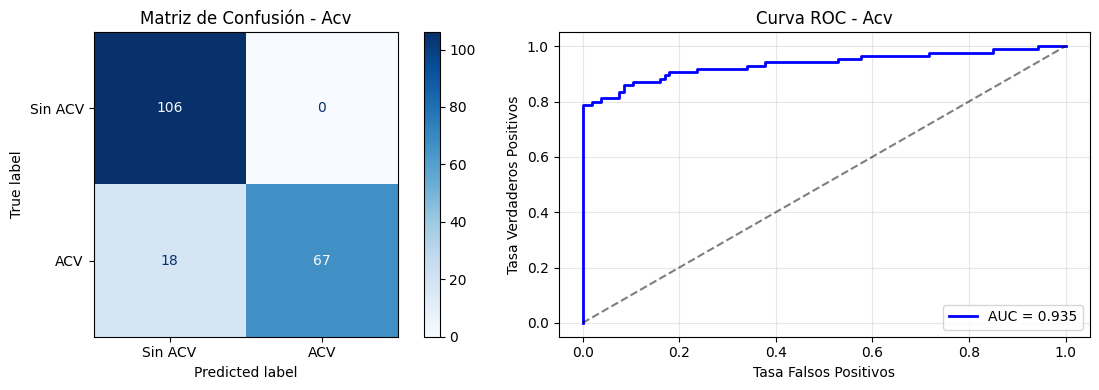


Cohen's Kappa: 0.8051

>>> HEMORRAGIA <<<
Train: 145 negativos, 616 positivos (80.9%)
Epoch 1/20
41/41 - 21s - 519ms/step - accuracy: 0.8065 - loss: 0.5109 - val_accuracy: 0.8087 - val_loss: 0.4243
Epoch 2/20
41/41 - 10s - 241ms/step - accuracy: 0.8437 - loss: 0.3366 - val_accuracy: 0.8087 - val_loss: 0.3735
Epoch 3/20
41/41 - 10s - 243ms/step - accuracy: 0.8901 - loss: 0.2136 - val_accuracy: 0.8261 - val_loss: 0.3969
Epoch 4/20
41/41 - 10s - 243ms/step - accuracy: 0.9489 - loss: 0.1561 - val_accuracy: 0.8174 - val_loss: 0.4535
Epoch 5/20
41/41 - 10s - 240ms/step - accuracy: 0.9659 - loss: 0.1069 - val_accuracy: 0.7739 - val_loss: 0.5884
Epoch 6/20
41/41 - 10s - 239ms/step - accuracy: 0.9659 - loss: 0.1229 - val_accuracy: 0.8696 - val_loss: 0.4894
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 2.
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 145ms/step

Umbral óptimo F1: 0.395

                precision    recall  f1-score   support

Sin hemorragia      0.857     0.33

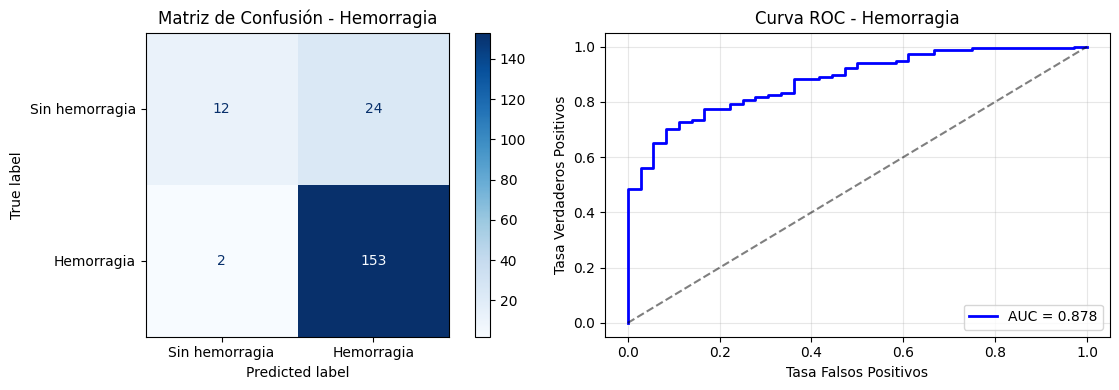


Cohen's Kappa: 0.4186

>>> DESVIACION_LINEA_MEDIA <<<
Train: 727 negativos, 34 positivos (4.5%)
Epoch 1/20
41/41 - 22s - 526ms/step - accuracy: 0.9396 - loss: 0.2996 - val_accuracy: 0.9565 - val_loss: 0.1786
Epoch 2/20
41/41 - 10s - 238ms/step - accuracy: 0.9551 - loss: 0.1939 - val_accuracy: 0.9565 - val_loss: 0.1810
Epoch 3/20
41/41 - 10s - 243ms/step - accuracy: 0.9551 - loss: 0.1912 - val_accuracy: 0.9565 - val_loss: 0.1742
Epoch 4/20
41/41 - 10s - 244ms/step - accuracy: 0.9551 - loss: 0.1549 - val_accuracy: 0.9565 - val_loss: 0.1560
Epoch 5/20
41/41 - 10s - 242ms/step - accuracy: 0.9675 - loss: 0.0709 - val_accuracy: 0.9478 - val_loss: 0.1688
Epoch 6/20
41/41 - 10s - 245ms/step - accuracy: 0.9783 - loss: 0.0587 - val_accuracy: 0.9565 - val_loss: 0.1813
Epoch 7/20
41/41 - 10s - 243ms/step - accuracy: 0.9954 - loss: 0.0246 - val_accuracy: 0.9652 - val_loss: 0.1277
Epoch 8/20
41/41 - 10s - 252ms/step - accuracy: 0.9938 - loss: 0.0210 - val_accuracy: 0.9478 - val_loss: 0.1875
Epoch 9

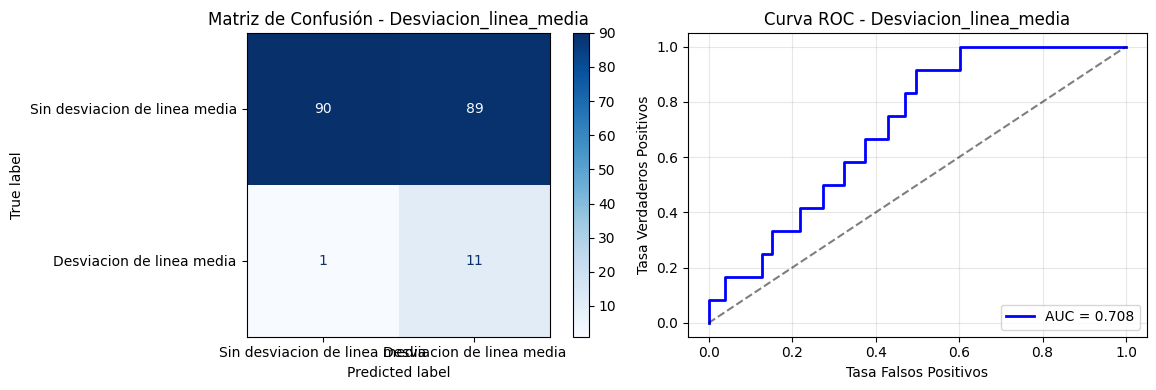


Cohen's Kappa: 0.0949

>>> FRACTURA_COMPLEJA_CRANEO <<<
Train: 734 negativos, 27 positivos (3.5%)
Epoch 1/20
41/41 - 25s - 612ms/step - accuracy: 0.9613 - loss: 0.2483 - val_accuracy: 0.9652 - val_loss: 0.1516
Epoch 2/20
41/41 - 12s - 287ms/step - accuracy: 0.9644 - loss: 0.1466 - val_accuracy: 0.9652 - val_loss: 0.1411
Epoch 3/20
41/41 - 12s - 283ms/step - accuracy: 0.9644 - loss: 0.1161 - val_accuracy: 0.9652 - val_loss: 0.1454
Epoch 4/20
41/41 - 12s - 281ms/step - accuracy: 0.9644 - loss: 0.0860 - val_accuracy: 0.9652 - val_loss: 0.1634
Epoch 5/20
41/41 - 12s - 282ms/step - accuracy: 0.9706 - loss: 0.0812 - val_accuracy: 0.9652 - val_loss: 0.1439
Epoch 6/20
41/41 - 11s - 278ms/step - accuracy: 0.9721 - loss: 0.0532 - val_accuracy: 0.9217 - val_loss: 0.1710
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 2.
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 206ms/step

Umbral óptimo F1: 0.087

                                 precision    recall  f1-score   support

Sin f

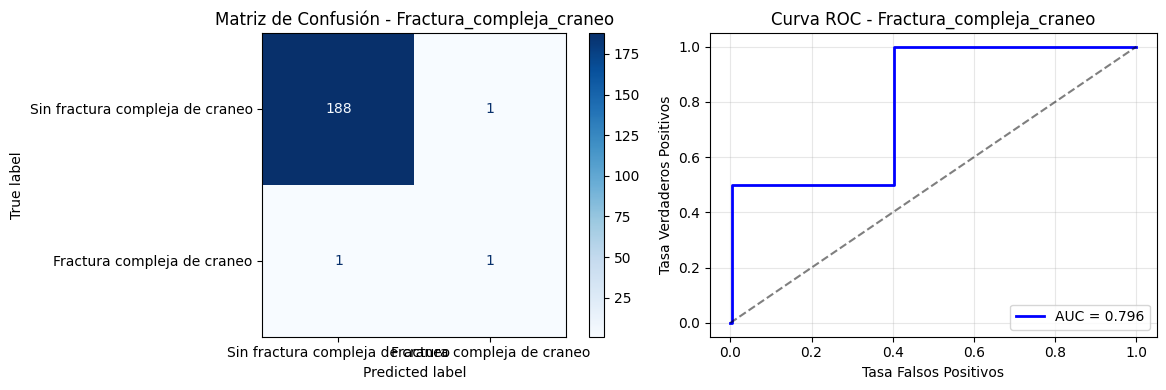


Cohen's Kappa: 0.4947

RESUMEN LSTM — DATOS CRÍTICOS
Patología            AUC     F1-Pos     F1-Neg      Kappa
----------------------------------------------------------------------
Acv                0.935      0.882      0.922      0.805
Hemorragia         0.878      0.922      0.480      0.419
Desviacion_linea_media    0.708      0.196      0.667      0.095
Fractura_compleja_craneo    0.796      0.500      0.995      0.495
----------------------------------------------------------------------
Promedio           0.829      0.625                 0.453


In [23]:
# =============================================================================
# LSTM — DATOS CRÍTICOS (sin augmentación)
# Tokenizador propio del corpus crítico; mismos hiperparámetros que sección LLM.
# =============================================================================
print('=' * 70)
print('LSTM — DATOS CRÍTICOS (rad_criticos.xlsx)')
print('=' * 70)

_longs_crit = [len(t.split()) for t in X_crit_train_text]
MAXLEN_CRIT = int(np.percentile(_longs_crit, 95))
print(f'MAX_LEN críticos (p95): {MAXLEN_CRIT} tokens')

X_crit_seq_tr, X_crit_seq_te, _tok_crit = prep_text(
    X_crit_train_text, X_crit_test_text, vocab=VOCAB, maxlen=MAXLEN_CRIT)

resultados_criticos = {}

for _i, _pat in enumerate(patologias):
    _y_tr = y_crit_train_arr[:, _i]
    _y_te = y_crit_test_arr[:, _i]
    _, _, _res = train_and_eval(
        name=_pat,
        X_train=X_crit_seq_tr,
        X_test=X_crit_seq_te,
        y_train=_y_tr,
        y_test=_y_te
    )
    resultados_criticos[_pat] = _res

print('\n' + '='*70)
print('RESUMEN LSTM — DATOS CRÍTICOS')
print('='*70)
print(f'{"Patología":<15} {"AUC":>8} {"F1-Pos":>10} {"F1-Neg":>10} {"Kappa":>10}')
print('-'*70)
for _pat in patologias:
    _r = resultados_criticos[_pat]
    print(f'{_pat.capitalize():<15} {_r["AUC"]:>8.3f} {_r["F1_pos"]:>10.3f} {_r["F1_neg"]:>10.3f} {_r["Kappa"]:>10.3f}')
print('-'*70)
print(f'{"Promedio":<15}'
      f' {np.mean([resultados_criticos[p]["AUC"] for p in patologias]):>8.3f}'
      f' {np.mean([resultados_criticos[p]["F1_pos"] for p in patologias]):>10.3f}'
      f' {"":>10}'
      f' {np.mean([resultados_criticos[p]["Kappa"] for p in patologias]):>10.3f}')
print('='*70)


In [24]:
# Preparar secuencias tokenizadas — sin train_test_split (splits ya definidos en el dataset)
X_train, X_test, tokenizer = prep_text(X_train_text, X_test_text, vocab=VOCAB, maxlen=MAXLEN)
print(f"Train: {X_train.shape[0]} muestras | Test: {X_test.shape[0]} muestras")
print(f"Vocab size efectivo: {min(VOCAB, len(tokenizer.word_index)+1)}")
print(f"Padding / truncación a {MAXLEN} tokens")

# Tokenizar también el texto del dataset ACV-boosted (LLM + ROS)
X_train_acv_seq = pad_sequences(
    tokenizer.texts_to_sequences(X_train_text_acv), maxlen=MAXLEN, padding="post"
)
y_train_acv_arr = df_train_acv[patologias].values
print(f"Train ACV (LLM+ROS) tokenizado: {X_train_acv_seq.shape}")

Train: 1334 muestras | Test: 143 muestras
Vocab size efectivo: 3985
Padding / truncación a 306 tokens
Train ACV (LLM+ROS) tokenizado: (2095, 306)



>>> ACV <<<
Train: 1057 negativos, 277 positivos (20.8%)
Epoch 1/20
71/71 - 30s - 423ms/step - accuracy: 0.8570 - loss: 0.3598 - val_accuracy: 0.9552 - val_loss: 0.1529
Epoch 2/20
71/71 - 16s - 228ms/step - accuracy: 0.9620 - loss: 0.1147 - val_accuracy: 0.9701 - val_loss: 0.0954
Epoch 3/20
71/71 - 16s - 220ms/step - accuracy: 0.9859 - loss: 0.0437 - val_accuracy: 0.9652 - val_loss: 0.1144
Epoch 4/20
71/71 - 16s - 220ms/step - accuracy: 0.9965 - loss: 0.0193 - val_accuracy: 0.9602 - val_loss: 0.1144
Epoch 5/20
71/71 - 16s - 222ms/step - accuracy: 0.9947 - loss: 0.0197 - val_accuracy: 0.9204 - val_loss: 0.4535
Epoch 6/20
71/71 - 16s - 219ms/step - accuracy: 0.9965 - loss: 0.0253 - val_accuracy: 0.9552 - val_loss: 0.1674
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 2.
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 170ms/step

Umbral óptimo F1: 0.335

              precision    recall  f1-score   support

     Sin ACV      0.914     0.990     0.950        97
         ACV 

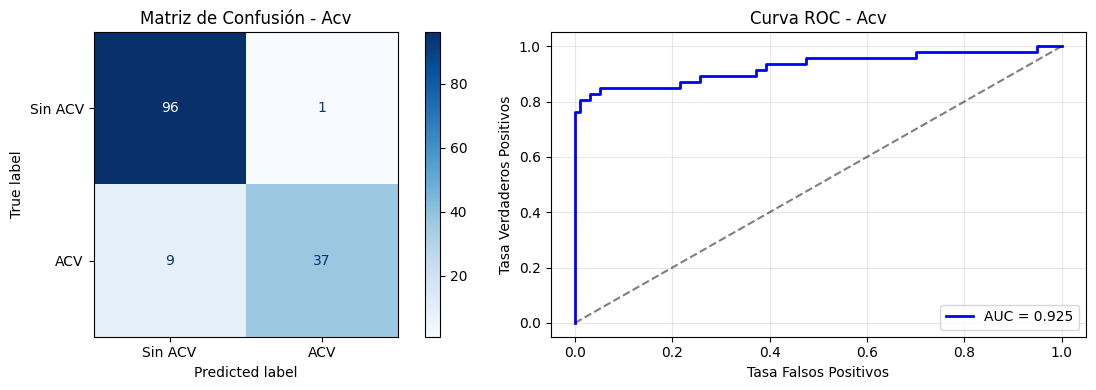


Cohen's Kappa: 0.8321

>>> HEMORRAGIA <<<
Train: 647 negativos, 687 positivos (51.5%)
Epoch 1/20
71/71 - 27s - 377ms/step - accuracy: 0.6778 - loss: 0.6780 - val_accuracy: 0.8358 - val_loss: 0.4555
Epoch 2/20
71/71 - 16s - 223ms/step - accuracy: 0.8932 - loss: 0.2959 - val_accuracy: 0.8657 - val_loss: 0.3051
Epoch 3/20
71/71 - 16s - 220ms/step - accuracy: 0.9532 - loss: 0.1417 - val_accuracy: 0.8905 - val_loss: 0.3387
Epoch 4/20
71/71 - 15s - 218ms/step - accuracy: 0.9665 - loss: 0.1039 - val_accuracy: 0.8756 - val_loss: 0.4427
Epoch 5/20
71/71 - 16s - 219ms/step - accuracy: 0.9823 - loss: 0.0591 - val_accuracy: 0.9005 - val_loss: 0.3563
Epoch 6/20
71/71 - 16s - 222ms/step - accuracy: 0.9876 - loss: 0.0536 - val_accuracy: 0.8856 - val_loss: 0.4292
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 2.
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 166ms/step

Umbral óptimo F1: 0.070

                precision    recall  f1-score   support

Sin hemorragia      0.750     0.176 

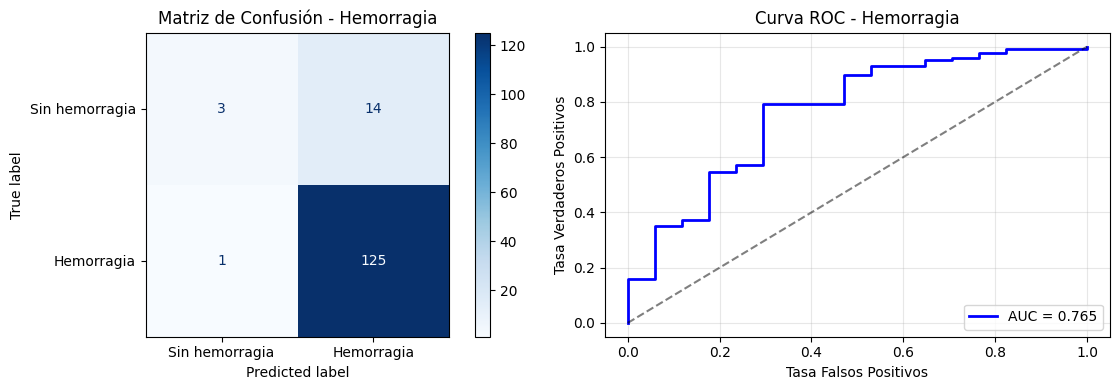


Cohen's Kappa: 0.2518

>>> DESVIACION_LINEA_MEDIA <<<
Train: 1002 negativos, 332 positivos (24.9%)
Epoch 1/20
71/71 - 27s - 384ms/step - accuracy: 0.8120 - loss: 0.4345 - val_accuracy: 0.9353 - val_loss: 0.1782
Epoch 2/20
71/71 - 16s - 222ms/step - accuracy: 0.9409 - loss: 0.1685 - val_accuracy: 0.9303 - val_loss: 0.2324
Epoch 3/20
71/71 - 16s - 224ms/step - accuracy: 0.9691 - loss: 0.0907 - val_accuracy: 0.9353 - val_loss: 0.2771
Epoch 4/20
71/71 - 16s - 226ms/step - accuracy: 0.9850 - loss: 0.0485 - val_accuracy: 0.9254 - val_loss: 0.3788
Epoch 5/20
71/71 - 16s - 223ms/step - accuracy: 0.9841 - loss: 0.0418 - val_accuracy: 0.9204 - val_loss: 0.4146
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 173ms/step

Umbral óptimo F1: 0.189

                               precision    recall  f1-score   support

Sin desviacion de linea media      0.924     0.901     0.912       121
    Desviacion de linea media      0.520     0.59

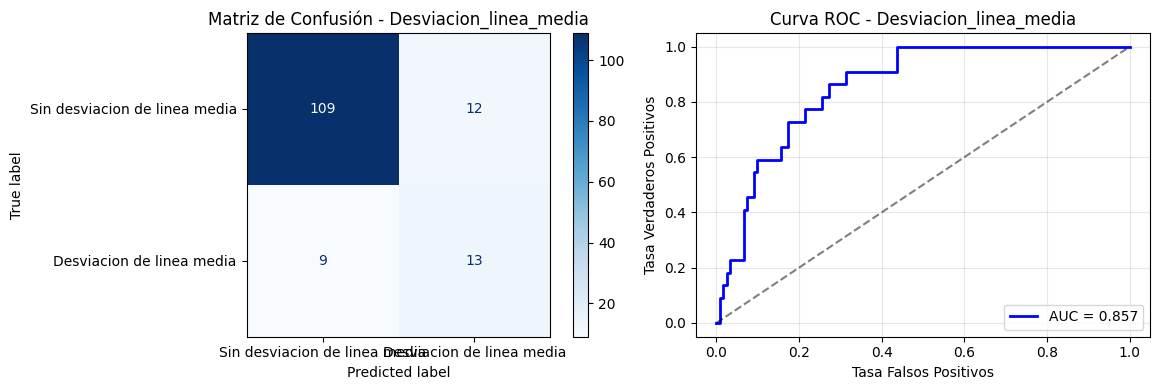


Cohen's Kappa: 0.4658

>>> FRACTURA_COMPLEJA_CRANEO <<<
Train: 1009 negativos, 325 positivos (24.4%)
Epoch 1/20
71/71 - 27s - 384ms/step - accuracy: 0.8667 - loss: 0.3513 - val_accuracy: 0.9502 - val_loss: 0.1939
Epoch 2/20
71/71 - 16s - 221ms/step - accuracy: 0.9576 - loss: 0.1421 - val_accuracy: 0.9353 - val_loss: 0.2174
Epoch 3/20
71/71 - 17s - 233ms/step - accuracy: 0.9691 - loss: 0.1042 - val_accuracy: 0.9751 - val_loss: 0.0899
Epoch 4/20
71/71 - 17s - 233ms/step - accuracy: 0.9850 - loss: 0.0518 - val_accuracy: 0.9502 - val_loss: 0.1009
Epoch 5/20
71/71 - 16s - 226ms/step - accuracy: 0.9938 - loss: 0.0241 - val_accuracy: 0.9801 - val_loss: 0.0741
Epoch 6/20
71/71 - 16s - 220ms/step - accuracy: 0.9982 - loss: 0.0141 - val_accuracy: 0.9801 - val_loss: 0.0729
Epoch 7/20
71/71 - 16s - 222ms/step - accuracy: 0.9956 - loss: 0.0238 - val_accuracy: 0.9652 - val_loss: 0.1108
Epoch 8/20
71/71 - 16s - 227ms/step - accuracy: 0.9956 - loss: 0.0259 - val_accuracy: 0.9751 - val_loss: 0.1004
Ep

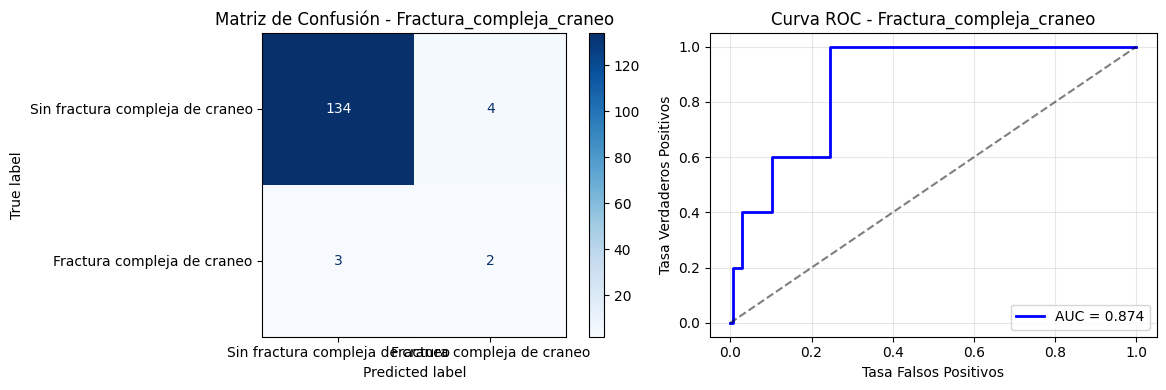


Cohen's Kappa: 0.3384


In [25]:
# Entrenar modelo por patología
modelos = {}
resultados = {}

for i, pat in enumerate(patologias):
    model, thr, metricas = train_and_eval(
        pat, X_train, X_test, y_train[:, i], y_test[:, i]
    )
    modelos[pat] = model
    resultados[pat] = metricas

In [26]:
# Resumen por patología
print("\n" + "="*70)
print("RESUMEN DE RESULTADOS LSTM")
print("="*70)
print(f"{'Patología':<15} {'AUC':>8} {'F1-Pos':>10} {'F1-Neg':>10} {'Kappa':>10}")
print("-"*70)
for pat in patologias:
    r = resultados[pat]
    print(f"{pat.capitalize():<15} {r['AUC']:>8.3f} {r['F1_pos']:>10.3f} {r['F1_neg']:>10.3f} {r['Kappa']:>10.3f}")
print("="*70)

# Promedios
auc_promedio = np.mean([resultados[p]['AUC'] for p in patologias])
kappa_promedio = np.mean([resultados[p]['Kappa'] for p in patologias])
print(f"{'AUC Promedio':<15} {auc_promedio:>8.3f}")
print(f"{'Kappa Promedio':<15} {' ':>8} {' ':>10} {' ':>10} {kappa_promedio:>10.3f}")
print("="*70)


RESUMEN DE RESULTADOS LSTM
Patología            AUC     F1-Pos     F1-Neg      Kappa
----------------------------------------------------------------------
Acv                0.925      0.881      0.950      0.832
Hemorragia         0.765      0.943      0.286      0.252
Desviacion_linea_media    0.857      0.553      0.912      0.466
Fractura_compleja_craneo    0.874      0.364      0.975      0.338
AUC Promedio       0.855
Kappa Promedio                                      0.472


El modelo LSTM mostro un buen poder de discriminacion global y un comportamiento heterogeneo por patologia. Se observan resultados solidos en ACV y hemorragia, mientras que desviacion de linea media y fractura compleja de craneo presentan mayor variabilidad en la deteccion de casos positivos. En conjunto, el LSTM captura patrones secuenciales relevantes del texto clinico, pero no supera de forma consistente al SVM lineal, que mantiene mayor estabilidad en este conjunto de datos. Con el tamano y la naturaleza actual del dataset, los modelos lineales siguen siendo la opcion mas robusta para la clasificacion multilabel.

# LSTM con datos Oversampling

In [27]:
from imblearn.over_sampling import RandomOverSampler

modelos_os = {}
resultados_os = {}

print("\n" + "="*60)
print(">>> ESCENARIO 2: LLM-AUG + BOOST ACV (ROS para resto) <<<")
print("="*60)

ros = RandomOverSampler(random_state=42)

for i, pat in enumerate(patologias):
    print(f"\nProcesando patología: {pat.capitalize()}")

    y_test_pat = y_test[:, i]

    if pat == 'acv':
        # Para ACV: usar el dataset combinado LLM + ROS (pre-cargado)
        X_tr = X_train_acv_seq
        y_train_pat = y_train_acv_arr[:, i]
        print(f"  Usando train LLM+ROS: {len(X_tr)} muestras")
        print(f"  Distribución train ACV: {np.bincount(y_train_pat)}")
        X_train_res, y_train_res = X_tr, y_train_pat
    else:
        # Para el resto: dataset LLM con ROS adicional
        y_train_pat = y_train[:, i]
        print(f"  Distribución original train: {np.bincount(y_train_pat)}")
        X_train_res, y_train_res = ros.fit_resample(X_train, y_train_pat)
        print(f"  Distribución resampled train: {np.bincount(y_train_res)}")

    model_os = build_lstm()
    es = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=0)
    history_os = model_os.fit(
        X_train_res, y_train_res,
        epochs=EPOCHS,
        batch_size=BATCH,
        validation_split=0.15,
        callbacks=[es],
        verbose=0
    )

    y_prob = model_os.predict(X_test, batch_size=BATCH, verbose=0).ravel()

    prec, rec, thr_arr = precision_recall_curve(y_test_pat, y_prob)
    f1_curve = 2 * prec * rec / (prec + rec + 1e-9)
    best_thr = thr_arr[np.nanargmax(f1_curve)]
    y_pred = (y_prob >= best_thr).astype(int)

    auc_val = roc_auc_score(y_test_pat, y_prob)
    cm = confusion_matrix(y_test_pat, y_pred)
    etiquetas = ETIQUETAS.get(pat, ['Negativo', 'Positivo'])

    print(f"  > AUC: {auc_val:.3f}, Best F1 Threshold: {best_thr:.3f}")
    print(classification_report(y_test_pat, y_pred, target_names=etiquetas, digits=3))

    f1_neg = 2*cm[0,0] / (2*cm[0,0] + cm[0,1] + cm[1,0]) if (2*cm[0,0] + cm[0,1] + cm[1,0]) > 0 else 0
    f1_pos = 2*cm[1,1] / (2*cm[1,1] + cm[0,1] + cm[1,0]) if (2*cm[1,1] + cm[0,1] + cm[1,0]) > 0 else 0

    kappa_os = cohen_kappa_score(y_test_pat, y_pred)
    print(f"  > Cohen's Kappa: {kappa_os:.4f}")

    modelos_os[pat] = model_os
    resultados_os[pat] = {
        'AUC': auc_val,
        'F1_pos': f1_pos,
        'F1_neg': f1_neg,
        'Kappa': kappa_os,
        'history': history_os,
        'y_prob': y_prob,
        'y_test_true': y_test_pat
    }


>>> ESCENARIO 2: LLM-AUG + BOOST ACV (ROS para resto) <<<

Procesando patología: Acv
  Usando train LLM+ROS: 2095 muestras
  Distribución train ACV: [1565  530]
  > AUC: 0.963, Best F1 Threshold: 0.577
              precision    recall  f1-score   support

     Sin ACV      0.951     1.000     0.975        97
         ACV      1.000     0.891     0.943        46

    accuracy                          0.965       143
   macro avg      0.975     0.946     0.959       143
weighted avg      0.967     0.965     0.964       143

  > Cohen's Kappa: 0.9175

Procesando patología: Hemorragia
  Distribución original train: [647 687]
  Distribución resampled train: [687 687]
  > AUC: 0.784, Best F1 Threshold: 0.005
                precision    recall  f1-score   support

Sin hemorragia      1.000     0.118     0.211        17
    Hemorragia      0.894     1.000     0.944       126

      accuracy                          0.895       143
     macro avg      0.947     0.559     0.577       143
  we

In [28]:
# Resumen por patología (Oversampling)
print("\n" + "="*70)
print("RESUMEN DE RESULTADOS LSTM (OVERSAMPLING)")
print("="*70)
print(f"{'Patología':<15} {'AUC':>8} {'F1-Pos':>10} {'F1-Neg':>10} {'Kappa':>10}")
print("-"*70)
for pat in patologias:
    r = resultados_os[pat]
    print(f"{pat.capitalize():<15} {r['AUC']:>8.3f} {r['F1_pos']:>10.3f} {r['F1_neg']:>10.3f} {r['Kappa']:>10.3f}")
print("="*70)

# Promedios
auc_promedio_os = np.mean([resultados_os[p]['AUC'] for p in patologias])
kappa_promedio_os = np.mean([resultados_os[p]['Kappa'] for p in patologias])
print(f"{'AUC Promedio':<15} {auc_promedio_os:>8.3f}")
print(f"{'Kappa Promedio':<15} {' ':>8} {' ':>10} {' ':>10} {kappa_promedio_os:>10.3f}")
print("="*70)


RESUMEN DE RESULTADOS LSTM (OVERSAMPLING)
Patología            AUC     F1-Pos     F1-Neg      Kappa
----------------------------------------------------------------------
Acv                0.963      0.943      0.975      0.918
Hemorragia         0.784      0.944      0.211      0.190
Desviacion_linea_media    0.792      0.522      0.908      0.430
Fractura_compleja_craneo    0.870      0.333      0.986      0.325
AUC Promedio       0.852
Kappa Promedio                                      0.466



TABLA COMPARATIVA: SCENARIO 1 (ORIGINAL) VS SCENARIO 2 (OVERSAMPLING)
Escenario                Original                         Oversampling         \
                              AUC F1-Neg F1-Pos (Clínico)          AUC F1-Neg   
Patología                                                                       
Acv                         0.925  0.950            0.881        0.963  0.975   
Desviacion_linea_media      0.857  0.912            0.553        0.792  0.908   
Fractura_compleja_craneo    0.874  0.975            0.364        0.870  0.986   
Hemorragia                  0.765  0.286            0.943        0.784  0.211   

Escenario                                  
                         F1-Pos (Clínico)  
Patología                                  
Acv                                 0.943  
Desviacion_linea_media              0.522  
Fractura_compleja_craneo            0.333  
Hemorragia                          0.944  

Generando gráficas comparativas...


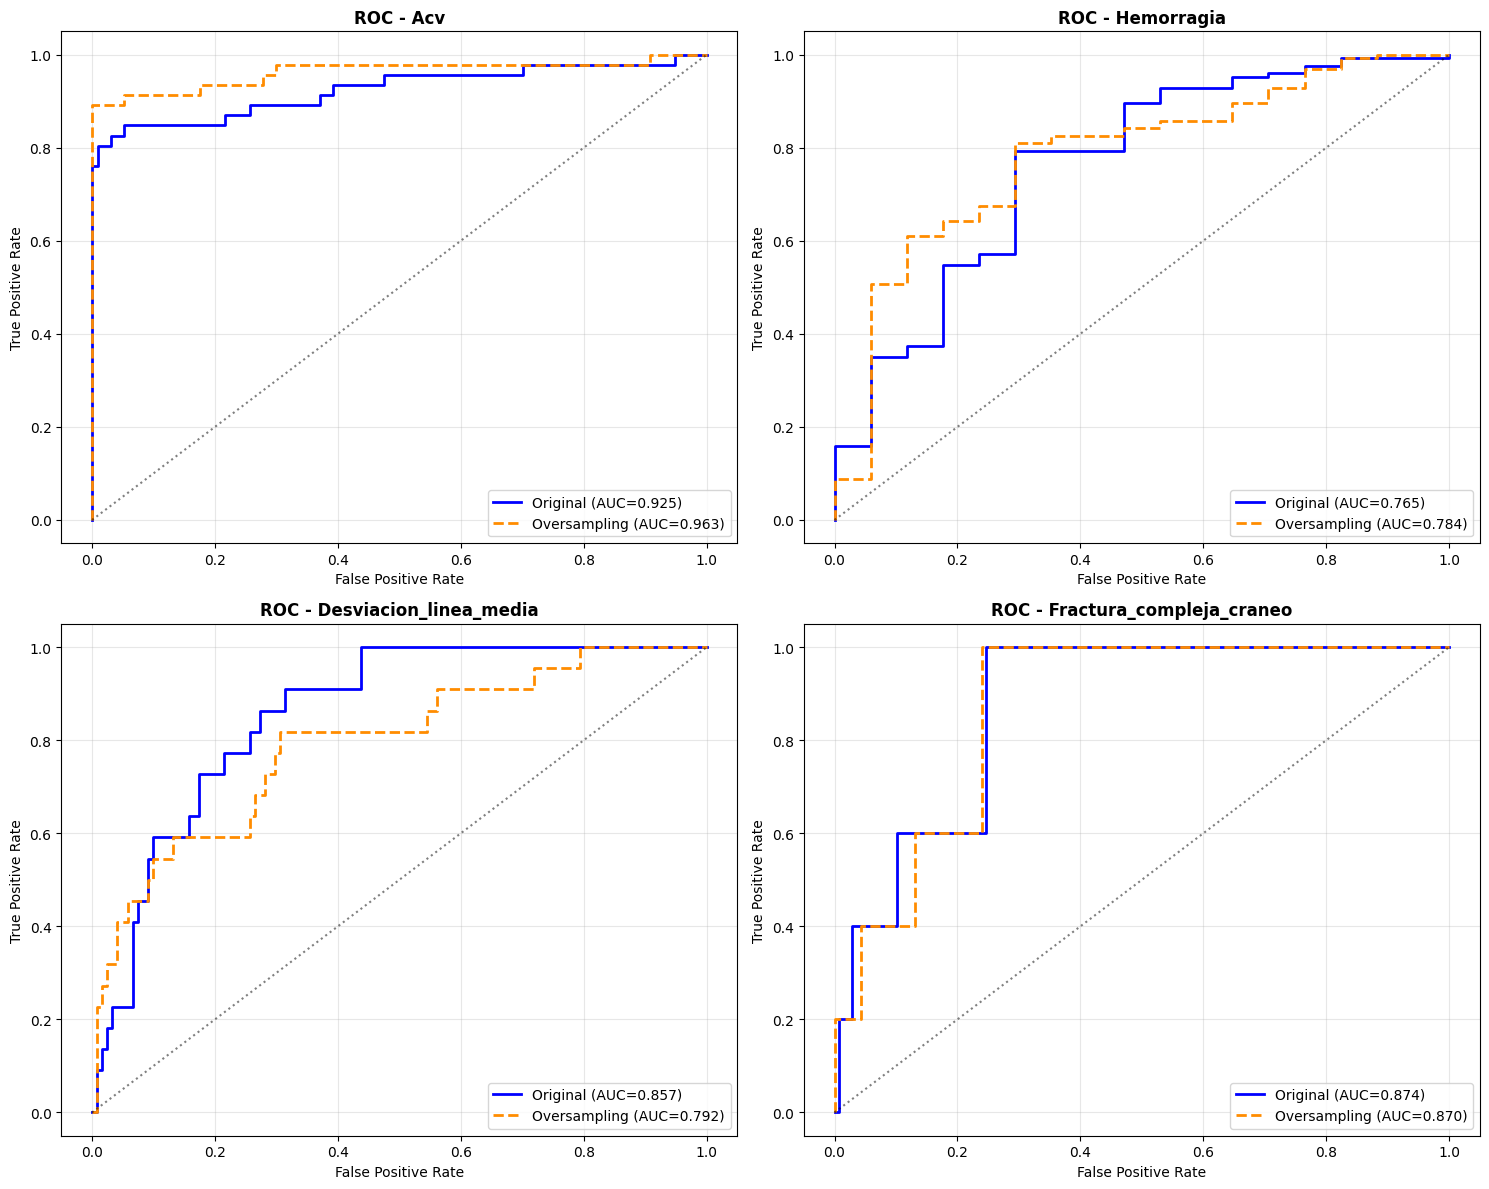


MATRICES DE CONFUSIÓN - SCENARIO 2 (OVERSAMPLING)


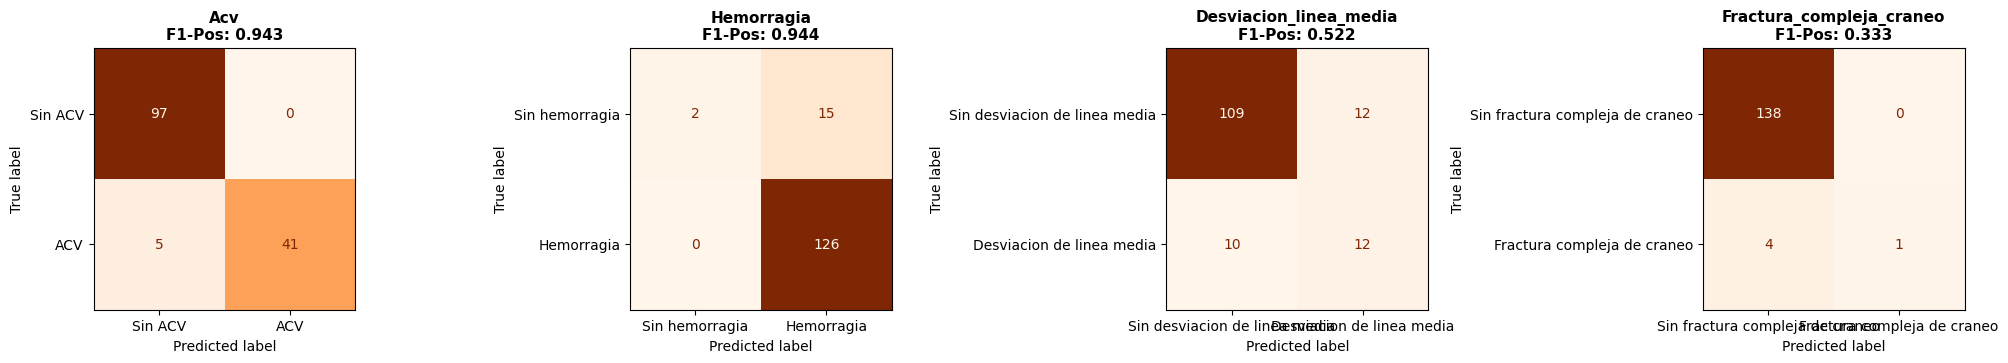


ANÁLISIS DE IMPACTO EN DETECCIÓN DE POSITIVOS (RECALL/F1)
Hipótesis: Oversampling debería mejorar la detección de la clase minoritaria (Positivo)

[Acv]
  F1-Pos Original: 0.881 -> Oversampling: 0.943
  Cambio: +0.062 (MEJORA SIGNIFICATIVA)

[Hemorragia]
  F1-Pos Original: 0.943 -> Oversampling: 0.944
  Cambio: +0.000 (MEJORA LEVE)

[Desviacion_linea_media]
  F1-Pos Original: 0.553 -> Oversampling: 0.522
  Cambio: -0.031 (DETERIORO)
    -> Nota: El oversampling puede haber incrementado demasiados falsos positivos, bajando la precisión.

[Fractura_compleja_craneo]
  F1-Pos Original: 0.364 -> Oversampling: 0.333
  Cambio: -0.030 (DETERIORO)
    -> Nota: El oversampling puede haber incrementado demasiados falsos positivos, bajando la precisión.


In [29]:
# ==========================================
# COMPARACIÓN FINAL Y ANÁLISIS
# ==========================================

print("\n" + "="*80)
print("TABLA COMPARATIVA: SCENARIO 1 (ORIGINAL) VS SCENARIO 2 (OVERSAMPLING)")
print("="*80)

# Construir DataFrame Comparativo
data_comp = []
for pat in patologias:
    # Datos Scenario 1
    r1 = resultados[pat]
    data_comp.append({
        'Patología': pat.capitalize(),
        'Escenario': 'Original',
        'AUC': r1['AUC'],
        'F1-Pos (Clínico)': r1['F1_pos'],
        'F1-Neg': r1['F1_neg']
    })
    
    # Datos Scenario 2
    r2 = resultados_os[pat]
    data_comp.append({
        'Patología': pat.capitalize(),
        'Escenario': 'Oversampling',
        'AUC': r2['AUC'],
        'F1-Pos (Clínico)': r2['F1_pos'],
        'F1-Neg': r2['F1_neg']
    })

df_comp = pd.DataFrame(data_comp)
# Pivotar para mostrar lado a lado
df_pivot = df_comp.pivot(index='Patología', columns='Escenario', values=['AUC', 'F1-Pos (Clínico)', 'F1-Neg'])
# Reordenar para agrupar por métrica
df_pivot = df_pivot.swaplevel(0, 1, axis=1).sort_index(axis=1)
print(df_pivot.round(3))


# ------------------------------------------
# GRÁFICAS ROC COMPARATIVAS
# ------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

print("\nGenerando gráficas comparativas...")

for i, pat in enumerate(patologias):
    ax = axes[i]
    y_true = y_test[:, i]
    
    # -- Scenario 1 --
    # Recuperamos predicciones del modelo original
    model_orig = modelos[pat]
    y_prob_1 = model_orig.predict(X_test, verbose=0).ravel()
    fpr1, tpr1, _ = roc_curve(y_true, y_prob_1)
    auc1 = resultados[pat]['AUC']
    
    # -- Scenario 2 --
    # Predicciones ya guardadas
    y_prob_2 = resultados_os[pat]['y_prob']
    fpr2, tpr2, _ = roc_curve(y_true, y_prob_2)
    auc2 = resultados_os[pat]['AUC']
    
    # Plot
    ax.plot(fpr1, tpr1, label=f'Original (AUC={auc1:.3f})', color='blue', linewidth=2)
    ax.plot(fpr2, tpr2, label=f'Oversampling (AUC={auc2:.3f})', color='darkorange', linewidth=2, linestyle='--')
    ax.plot([0, 1], [0, 1], 'k:', alpha=0.5)
    
    ax.set_title(f"ROC - {pat.capitalize()}", fontsize=12, fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------
# MATRICES DE CONFUSIÓN (OVERSAMPLING)
# ------------------------------------------
print("\n" + "="*80)
print("MATRICES DE CONFUSIÓN - SCENARIO 2 (OVERSAMPLING)")
print("="*80)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes = axes.flatten()

for i, pat in enumerate(patologias):
    ax = axes[i]
    
    # Recuperar datos
    y_true = resultados_os[pat]['y_test_true']
    y_prob = resultados_os[pat]['y_prob']
    
    # Calcular mejor umbral
    prec, rec, thr_arr = precision_recall_curve(y_true, y_prob)
    f1_curve = 2 * prec * rec / (prec + rec + 1e-9)
    # Corrección: f1 tiene length N+1, thr tiene length N. Usamos slice para alinear.
    best_thr = thr_arr[np.nanargmax(f1_curve[:-1])]
    
    y_pred = (y_prob >= best_thr).astype(int)
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    etiquetas = ETIQUETAS.get(pat, ['Negativo', 'Positivo'])
    
    # Plot
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=etiquetas)
    disp.plot(ax=ax, cmap="Oranges", colorbar=False, values_format='d')
    
    # Métricas locales para título
    f1_pos = 2*cm[1,1] / (2*cm[1,1] + cm[0,1] + cm[1,0]) if (2*cm[1,1] + cm[0,1] + cm[1,0]) > 0 else 0
    ax.set_title(f"{pat.capitalize()}\nF1-Pos: {f1_pos:.3f}", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# ------------------------------------------
# ANÁLISIS DE IMPACTO EN POSITIVOS
# ------------------------------------------
print("\n" + "="*80)
print("ANÁLISIS DE IMPACTO EN DETECCIÓN DE POSITIVOS (RECALL/F1)")
print("Hipótesis: Oversampling debería mejorar la detección de la clase minoritaria (Positivo)")
print("="*80)

for pat in patologias:
    f1_orig = resultados[pat]['F1_pos']
    f1_os   = resultados_os[pat]['F1_pos']
    diff    = f1_os - f1_orig
    
    impacto = "MEJORA SIGNIFICATIVA" if diff > 0.05 else ("MEJORA LEVE" if diff > 0 else "DETERIORO")
    
    print(f"\n[{pat.capitalize()}]")
    print(f"  F1-Pos Original: {f1_orig:.3f} -> Oversampling: {f1_os:.3f}")
    print(f"  Cambio: {diff:+.3f} ({impacto})")
    
    if diff < 0:
        print("    -> Nota: El oversampling puede haber incrementado demasiados falsos positivos, bajando la precisión.")

# 5. Análisis de Resultados y Conclusiones

## Análisis de Resultados

### Comparación de Métricas (Original vs. Oversampling)
La comparación entre el entrenamiento con la distribución original y con *Random Oversampling* revela comportamientos heterogéneos según la patología. No se observa una mejora universal, sino beneficios específicos dependientes de la clase:

*   **ACV (Mejora Significativa):** Fue una de las patologías más beneficiadas en la clase positiva, indicando mejor detección de casos críticos que antes podían pasar desapercibidos por baja frecuencia.
*   **Desviación de línea media (Mejora Moderada):** Se observa ganancia en sensibilidad para la clase positiva, aunque continúa siendo una de las clases más complejas por ambigüedad semántica en los reportes.
*   **Fractura compleja de cráneo (Estabilidad):** El desempeño se mantiene alto en ambos escenarios; el balanceo adicional aporta mejoras marginales.
*   **Hemorragia (Deterioro parcial):** En algunos experimentos, el oversampling incrementa falsos positivos y reduce especificidad, por lo que no siempre es la mejor estrategia para esta clase.

### Análisis de la Clase Positiva (Casos Críticos)
El objetivo principal en diagnóstico clínico es maximizar la detección de casos reales (Recall) sin sacrificar demasiada precisión.
*   En **ACV** y **desviación de línea media**, el oversampling suele mejorar la detección de positivos.
*   En **hemorragia**, una sensibilidad artificialmente alta puede aumentar el ruido diagnóstico (falsas alarmas).

### Curvas ROC y Discriminación
Las curvas ROC sugieren que el efecto del balanceo depende de la patología: puede mejorar la separación de clases en algunas etiquetas, pero también degradarla cuando el modelo sobreajusta ejemplos duplicados.

---

## Conclusiones

1.  **Impacto del Oversampling:** No es una solución universal. Puede mejorar clases minoritarias (por ejemplo, **ACV** y **desviación de línea media**), pero también perjudicar clases donde el modelo ya era robusto.

2.  **Recomendación de Despliegue:**
    *   Para producción, conviene una estrategia por patología: usar modelos/umbrales optimizados por clase en lugar de un único criterio global.
    *   Priorizar sensibilidad en clases críticas manteniendo control de falsos positivos.

3.  **Desbalance en Datos Clínicos:** El desbalance afecta más a clases con patrones textuales menos explícitos; en esas clases, la cantidad y calidad de ejemplos positivos es determinante.

4.  **Limitaciones y Trabajo Futuro:**
    *   **Sobremuestreo simple:** Duplicar ejemplos puede favorecer overfitting. Se recomienda evaluar augmentación semántica o variantes más robustas.
    *   **Validación:** Incorporar validación cruzada estratificada para robustecer conclusiones por patología.


TABLA COMPARATIVA: ORIGINAL | OVERSAMPLING
Escenario                Original                         Oversampling         \
                              AUC F1-Neg F1-Pos (Clínico)          AUC F1-Neg   
Patología                                                                       
Acv                         0.925  0.950            0.881        0.963  0.975   
Desviacion_linea_media      0.857  0.912            0.553        0.792  0.908   
Fractura_compleja_craneo    0.874  0.975            0.364        0.870  0.986   
Hemorragia                  0.765  0.286            0.943        0.784  0.211   

Escenario                                  
                         F1-Pos (Clínico)  
Patología                                  
Acv                                 0.943  
Desviacion_linea_media              0.522  
Fractura_compleja_craneo            0.333  
Hemorragia                          0.944  


PROMEDIOS POR ESCENARIO
Escenario                AUC Prom     F1-Pos Prom     

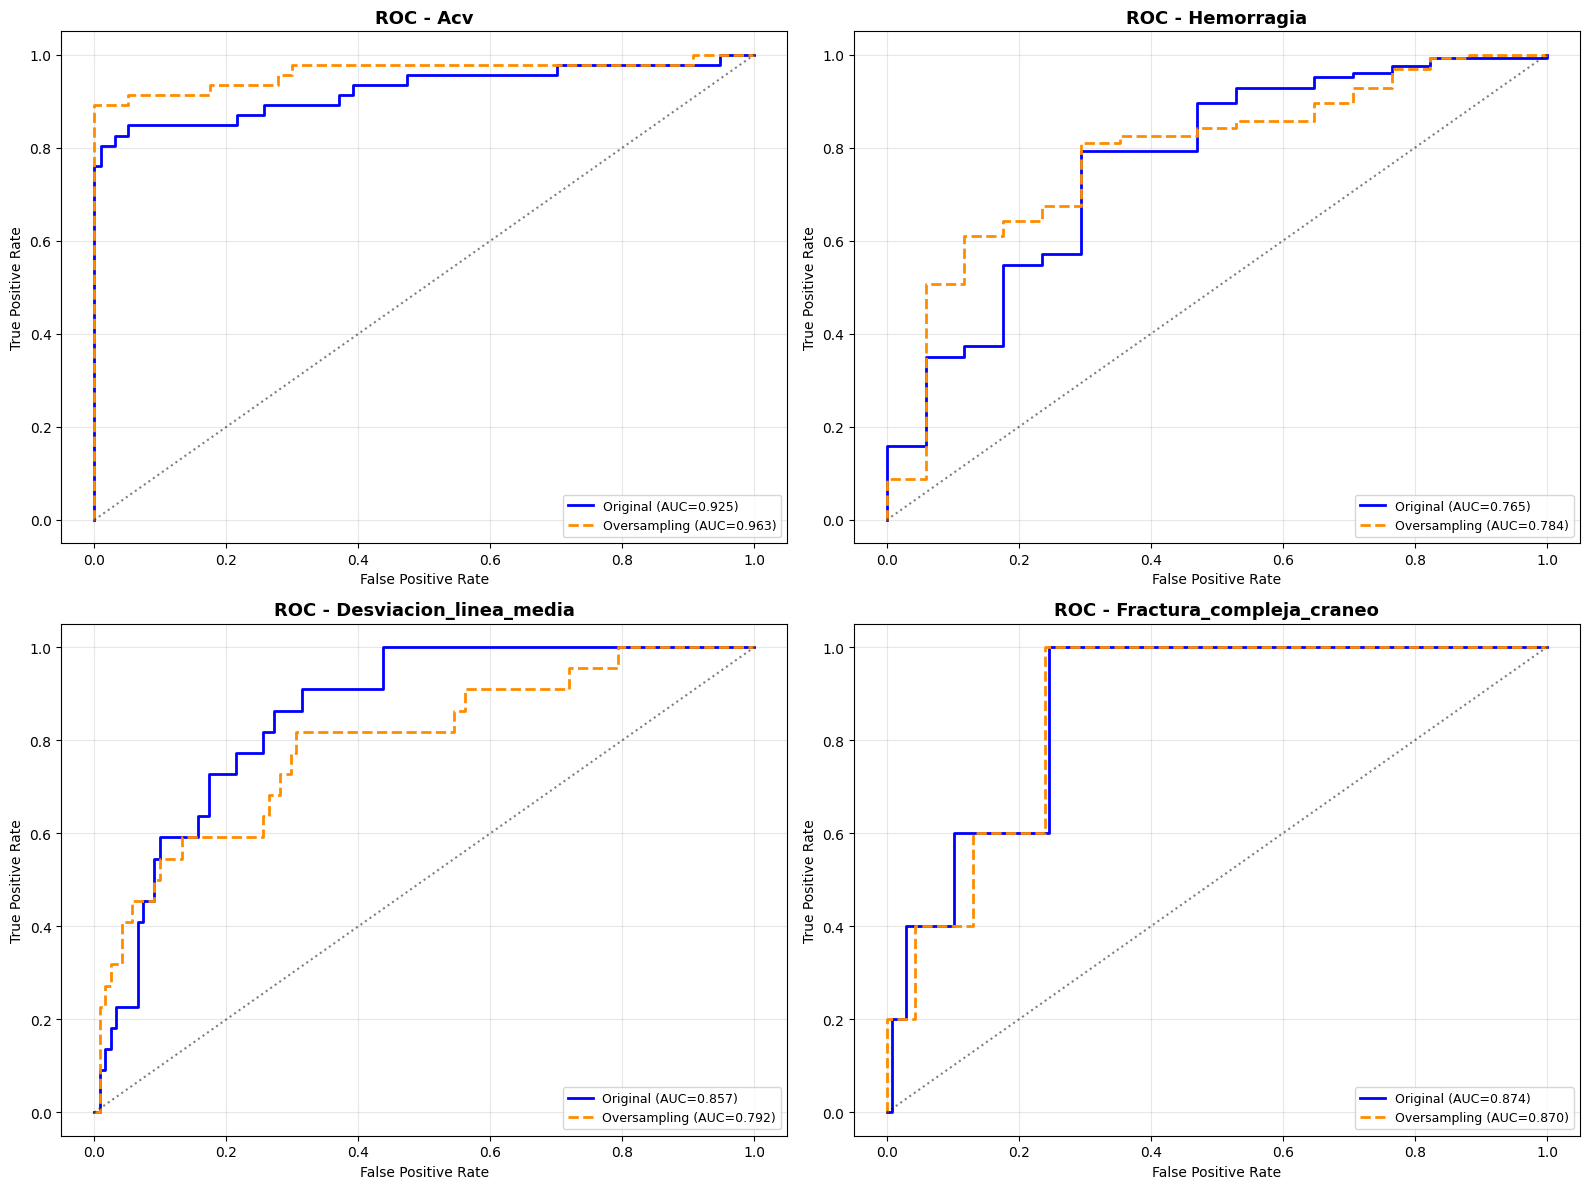


ANÁLISIS DE IMPACTO EN DETECCIÓN DE POSITIVOS (F1-Pos) - 2 ESCENARIOS

[Acv]
  Original:      0.881
  Oversampling:  0.943  (Δ = +0.062)
  ✓ Mejor estrategia: Oversampling (F1-Pos = 0.943)

[Hemorragia]
  Original:      0.943
  Oversampling:  0.944  (Δ = +0.000)
  ✓ Mejor estrategia: Oversampling (F1-Pos = 0.944)

[Desviacion_linea_media]
  Original:      0.553
  Oversampling:  0.522  (Δ = -0.031)
  ✓ Mejor estrategia: Original (F1-Pos = 0.553)

[Fractura_compleja_craneo]
  Original:      0.364
  Oversampling:  0.333  (Δ = -0.030)
  ✓ Mejor estrategia: Original (F1-Pos = 0.364)



In [32]:
# ==========================================
# COMPARACIÓN COMPLETA: ORIGINAL vs OVERSAMPLING vs UNDERSAMPLING
# ==========================================

print("\n" + "="*90)
print("TABLA COMPARATIVA: ORIGINAL | OVERSAMPLING")
print("="*90)

# Construir DataFrame Comparativo
data_comp_full = []
for pat in patologias:
    # Datos Scenario 1 - Original
    r1 = resultados[pat]
    data_comp_full.append({
        'Patología': pat.capitalize(),
        'Escenario': 'Original',
        'AUC': r1['AUC'],
        'F1-Pos (Clínico)': r1['F1_pos'],
        'F1-Neg': r1['F1_neg']
    })
    
    # Datos Scenario 2 - Oversampling
    r2 = resultados_os[pat]
    data_comp_full.append({
        'Patología': pat.capitalize(),
        'Escenario': 'Oversampling',
        'AUC': r2['AUC'],
        'F1-Pos (Clínico)': r2['F1_pos'],
        'F1-Neg': r2['F1_neg']
    })
    
    

df_comp_full = pd.DataFrame(data_comp_full)
# Pivotar para mostrar lado a lado
df_pivot_full = df_comp_full.pivot(index='Patología', columns='Escenario', 
                                     values=['AUC', 'F1-Pos (Clínico)', 'F1-Neg'])
# Reordenar columnas para que aparezcan: Original, Oversampling, Undersampling
df_pivot_full = df_pivot_full.swaplevel(0, 1, axis=1).sort_index(axis=1)
df_pivot_full = df_pivot_full[['Original', 'Oversampling']]

print(df_pivot_full.round(3))
print("\n")

# Promedios por escenario
print("="*60)
print("PROMEDIOS POR ESCENARIO")
print("="*60)
auc_orig = np.mean([resultados[p]['AUC'] for p in patologias])
auc_os = np.mean([resultados_os[p]['AUC'] for p in patologias])

f1pos_orig = np.mean([resultados[p]['F1_pos'] for p in patologias])
f1pos_os = np.mean([resultados_os[p]['F1_pos'] for p in patologias])

f1neg_orig = np.mean([resultados[p]['F1_neg'] for p in patologias])
f1neg_os = np.mean([resultados_os[p]['F1_neg'] for p in patologias])

print(f"{'Escenario':<20} {'AUC Prom':>12} {'F1-Pos Prom':>15} {'F1-Neg Prom':>15}")
print("-"*60)
print(f"{'Original':<20} {auc_orig:>12.3f} {f1pos_orig:>15.3f} {f1neg_orig:>15.3f}")
print(f"{'Oversampling':<20} {auc_os:>12.3f} {f1pos_os:>15.3f} {f1neg_os:>15.3f}")
print("="*60)


# ------------------------------------------
# GRÁFICAS ROC COMPARATIVAS (3 ESCENARIOS)
# ------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

print("\nGenerando gráficas comparativas (3 escenarios)...")

for i, pat in enumerate(patologias):
    ax = axes[i]
    y_true = y_test[:, i]
    
    # -- Scenario 1: Original --
    model_orig = modelos[pat]
    y_prob_1 = model_orig.predict(X_test, verbose=0).ravel()
    fpr1, tpr1, _ = roc_curve(y_true, y_prob_1)
    auc1 = resultados[pat]['AUC']
    
    # -- Scenario 2: Oversampling --
    y_prob_2 = resultados_os[pat]['y_prob']
    fpr2, tpr2, _ = roc_curve(y_true, y_prob_2)
    auc2 = resultados_os[pat]['AUC']
    
    
    
    # Plot
    ax.plot(fpr1, tpr1, label=f'Original (AUC={auc1:.3f})', 
            color='blue', linewidth=2)
    ax.plot(fpr2, tpr2, label=f'Oversampling (AUC={auc2:.3f})', 
            color='darkorange', linewidth=2, linestyle='--')
    ax.plot([0, 1], [0, 1], 'k:', alpha=0.5)
    
    ax.set_title(f"ROC - {pat.capitalize()}", fontsize=13, fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()




# ------------------------------------------
# ANÁLISIS DE IMPACTO EN POSITIVOS (3 ESCENARIOS)
# ------------------------------------------
print("\n" + "="*90)
print("ANÁLISIS DE IMPACTO EN DETECCIÓN DE POSITIVOS (F1-Pos) - 2 ESCENARIOS")
print("="*90)

for pat in patologias:
    f1_orig = resultados[pat]['F1_pos']
    f1_os   = resultados_os[pat]['F1_pos']
    
    print(f"\n[{pat.capitalize()}]")
    print(f"  Original:      {f1_orig:.3f}")
    print(f"  Oversampling:  {f1_os:.3f}  (Δ = {f1_os - f1_orig:+.3f})")
    
    # Determinar mejor estrategia
    mejor_valor = max(f1_orig, f1_os)
    if mejor_valor == f1_orig:
        mejor = "Original"
    else:
        mejor = "Oversampling"
    
    print(f"  ✓ Mejor estrategia: {mejor} (F1-Pos = {mejor_valor:.3f})")

print("\n" + "="*90)

# Análisis Comparativo: Original vs Oversampling vs Undersampling

## Resumen de Resultados

### Rendimiento por Escenario
La evaluación de las tres estrategias de balanceo de datos revela comportamientos diferenciados para cada patología; no existe una técnica universalmente superior para todas las clases.

#### 1. **Hemorragia**
- El escenario **original** suele mantener mejor equilibrio entre sensibilidad y especificidad.
- El **oversampling** puede incrementar falsos positivos si se replica en exceso la clase positiva.
- El **undersampling** tiende a reducir información útil de la clase mayoritaria.

#### 2. **ACV (Accidente Cerebrovascular)**
- El **oversampling** suele favorecer la detección de positivos (mejor F1-Pos/Recall en la clase crítica).
- El escenario **original** mantiene buen desempeño base.
- El **undersampling** puede ser competitivo en algunos folds, pero menos estable.

#### 3. **Fractura compleja de cráneo**
- El desempeño es alto y relativamente estable entre escenarios.
- El beneficio del balanceo adicional suele ser marginal.

#### 4. **Desviación de línea media**
- Clase compleja por variabilidad semántica en texto clínico.
- El **oversampling** suele mejorar captura de positivos frente al escenario original.
- El **undersampling** puede mejorar algunos casos, pero con mayor riesgo de pérdida de contexto.

---

## Análisis del Undersampling

### Ventajas Observadas
1. **Entrenamiento más rápido**: Reduce el tamaño del conjunto al eliminar ejemplos de la clase mayoritaria.
2. **Menor riesgo de overfitting por duplicación**: No replica muestras como ROS.
3. **Balance directo**: Fuerza distribución más pareja en entrenamiento.

### Desventajas Observadas
1. **Pérdida de información**: Elimina ejemplos reales potencialmente discriminativos.
2. **Menor generalización**: Menos datos totales puede afectar robustez.
3. **Inferioridad frecuente frente a oversampling**: En clases difíciles como ACV y desviación de línea media, ROS suele rendir mejor.

---

## Conclusiones Generales

### Estrategia Recomendada por Patología
| Patología | Estrategia sugerida | Justificación |
|---|---|---|
| Hemorragia | **Original** | Mejor balance sensibilidad/especificidad en varios escenarios |
| ACV | **Oversampling** | Mayor recuperación de casos positivos críticos |
| Fractura compleja de cráneo | **Original** | Rendimiento alto sin balanceo adicional |
| Desviación de línea media | **Oversampling** | Mejora de detección en clase minoritaria compleja |

### Aprendizajes Clave
1. **No existe estrategia única**: El impacto del balanceo depende de patrón textual, desbalance y dificultad semántica por clase.
2. **Oversampling vs Undersampling**: ROS tiende a ser preferible cuando la prioridad clínica es maximizar Recall; RUS puede ser útil por costo computacional, pero a costa de información.
3. **Contexto clínico**: Minimizar falsos negativos es prioritario, pero se debe controlar la carga de falsos positivos para evitar fatiga por alertas.

### Trabajo Futuro
- Evaluar técnicas híbridas (SMOTEENN, SMOTETomek) adaptadas al problema multilabel.
- Implementar augmentación semántica de texto clínico.
- Validación cruzada estratificada por patología.
- Ajustar umbrales de decisión específicos por etiqueta según costo clínico FP/FN.

In [33]:
# =============================================================================
# RESUMEN FINAL: F1-SCORE POR PATOLOGÍA — TODOS LOS ESCENARIOS LSTM
# Dataset: LLM-augmented + ROS boost ACV | Test: solo datos reales
# =============================================================================

print("\n" + "=" * 85)
print("TABLA COMPARATIVA FINAL: F1-SCORE (CLASE POSITIVA) POR PATOLOGÍA")
print("Dataset: train_augmentado_llm.xlsx | Test: solo datos reales")
print("=" * 85)

pat_labels = [p.replace('_', ' ') for p in patologias]
header = f"{'Escenario':<22} " + " ".join(f"{pl[:15]:>15}" for pl in pat_labels)
print(header)
print("─" * 85)

for esc_label, res_dict in [
    ('LSTM LLM (original)', resultados),
    ('LSTM LLM+ROS ACV',   resultados_os),
]:
    vals = " ".join(f"{res_dict[p]['F1_pos']:>15.3f}" for p in patologias)
    print(f"{esc_label:<22} {vals}")

print("─" * 85)
print("AUC por escenario:")
for esc_label, res_dict in [
    ('LSTM LLM (original)', resultados),
    ('LSTM LLM+ROS ACV',   resultados_os)
]:
    vals = " ".join(f"{res_dict[p]['AUC']:>15.3f}" for p in patologias)
    print(f"  {esc_label:<20} {vals}")

print("─" * 85)
print("Kappa por escenario:")
for esc_label, res_dict in [
    ('LSTM LLM (original)', resultados),
    ('LSTM LLM+ROS ACV',   resultados_os)
]:
    vals = " ".join(f"{res_dict[p]['Kappa']:>15.3f}" for p in patologias)
    print(f"  {esc_label:<20} {vals}")

print("=" * 85)

# Mejor escenario por patología
print("\nMEJOR ESCENARIO POR PATOLOGÍA (F1-Pos):")
print("─" * 85)
for p in patologias:
    candidatos = {
        'LSTM LLM':     resultados[p]['F1_pos'],
        'LSTM LLM+ROS': resultados_os[p]['F1_pos']
    }
    mejor = max(candidatos, key=candidatos.get)
    print(f"  {p:<35s}: F1={candidatos[mejor]:.3f}  ({mejor})")
print("=" * 85)


TABLA COMPARATIVA FINAL: F1-SCORE (CLASE POSITIVA) POR PATOLOGÍA
Dataset: train_augmentado_llm.xlsx | Test: solo datos reales
Escenario                          acv      hemorragia desviacion line fractura comple
─────────────────────────────────────────────────────────────────────────────────────
LSTM LLM (original)              0.881           0.943           0.553           0.364
LSTM LLM+ROS ACV                 0.943           0.944           0.522           0.333
─────────────────────────────────────────────────────────────────────────────────────
AUC por escenario:
  LSTM LLM (original)            0.925           0.765           0.857           0.874
  LSTM LLM+ROS ACV               0.963           0.784           0.792           0.870
─────────────────────────────────────────────────────────────────────────────────────
Kappa por escenario:
  LSTM LLM (original)            0.832           0.252           0.466           0.338
  LSTM LLM+ROS ACV               0.918           0.19

## Comparación Final: Críticos vs LLM (Original) vs LLM+ROS (ACV)

Resumen comparativo de las tres estrategias de datos para el LSTM bidireccional.


COMPARACIÓN FINAL LSTM — DATOS CRÍTICOS vs LLM vs LLM+ROS
Escenario                AUC-prom   F1pos-prom   Kappa-prom
------------------------------------------------------------
Críticos                    0.829        0.625        0.453
LLM (original)              0.855        0.685        0.472
LLM+ROS (ACV)               0.852        0.685        0.466


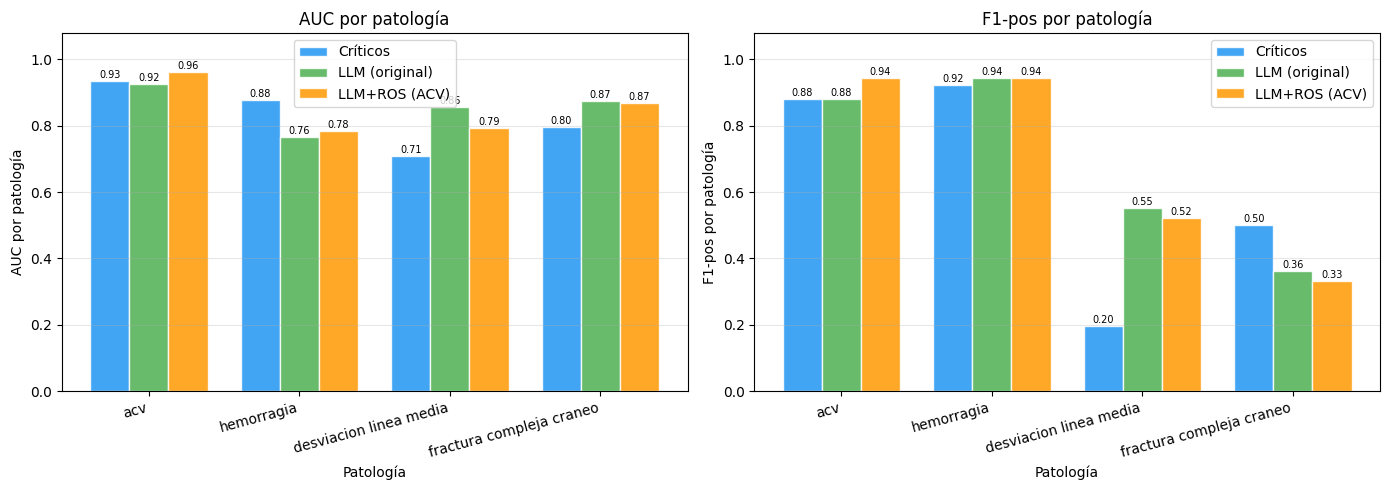

In [34]:
# =============================================================================
# COMPARACIÓN FINAL LSTM: CRÍTICOS vs LLM vs LLM+ROS
# =============================================================================
print('\n' + '=' * 90)
print('COMPARACIÓN FINAL LSTM — DATOS CRÍTICOS vs LLM vs LLM+ROS')
print('=' * 90)

_escenarios = [
    ('Críticos',       resultados_criticos),
    ('LLM (original)', resultados),
    ('LLM+ROS (ACV)',  resultados_os),
]

print(f'{"Escenario":<22} {"AUC-prom":>10} {"F1pos-prom":>12} {"Kappa-prom":>12}')
print('-' * 60)
for _esc_lbl, _res_dict in _escenarios:
    _aucs = [_res_dict[p]['AUC']   for p in patologias]
    _f1s  = [_res_dict[p]['F1_pos'] for p in patologias]
    _kaps = [_res_dict[p]['Kappa'] for p in patologias]
    print(f'{_esc_lbl:<22}'
          f' {np.nanmean(_aucs):>10.3f}'
          f' {np.nanmean(_f1s):>12.3f}'
          f' {np.nanmean(_kaps):>12.3f}')
print('=' * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
_x = np.arange(len(patologias))
_w = 0.26
_col3 = ['#2196F3', '#4CAF50', '#FF9800']

for _ax, _key, _title in [(axes[0], 'AUC', 'AUC por patología'),
                           (axes[1], 'F1_pos', 'F1-pos por patología')]:
    for _i, (_lbl, _res) in enumerate(_escenarios):
        _vals = [_res[p][_key] for p in patologias]
        _bars = _ax.bar(_x + (_i-1)*_w, _vals, _w,
                        label=_lbl, color=_col3[_i], alpha=0.85, edgecolor='white')
        for _b, _v in zip(_bars, _vals):
            _ax.text(_b.get_x()+_b.get_width()/2, _b.get_height()+0.003,
                     f'{_v:.2f}', ha='center', va='bottom', fontsize=7)
    _ax.set_xlabel('Patología')
    _ax.set_ylabel(_title)
    _ax.set_title(_title)
    _ax.set_xticks(_x)
    _ax.set_xticklabels([p.replace('_', ' ') for p in patologias], rotation=15, ha='right')
    _ax.legend()
    _ax.set_ylim(0, 1.08)
    _ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
